#📌 Extracción

In [1]:
import pandas as pd

# URL del archivo JSON raw en GitHub
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'

# Cargar los datos directamente desde la URL a un DataFrame de Pandas
try:
    df = pd.read_json(url)
    print("Datos cargados exitosamente en un DataFrame de Pandas.")
    print("Primeras 5 filas del DataFrame:")
    print(df.head())
    print("Información general del DataFrame:")
    df.info()
except Exception as e:
    print(f"Ocurrió un error al cargar los datos: {e}")

Datos cargados exitosamente en un DataFrame de Pandas.
Primeras 5 filas del DataFrame:
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', '

#🔧 Transformación

In [2]:
# Aplanar las columnas anidadas en nuevas columnas
df_flattened = pd.json_normalize(df['customer'])
df_flattened = pd.concat([df_flattened, pd.json_normalize(df['phone'])], axis=1)
df_flattened = pd.concat([df_flattened, pd.json_normalize(df['internet'])], axis=1)
df_flattened = pd.concat([df_flattened, pd.json_normalize(df['account'])], axis=1)

# Unir las nuevas columnas a df y eliminar las columnas originales anidadas
df = pd.concat([df.drop(columns=['customer', 'phone', 'internet', 'account']), df_flattened], axis=1)

print("DataFrame después de aplanar las columnas anidadas:")
print("Primeras 5 filas del DataFrame:")
print(df.head())
print("Información general del DataFrame:")
df.info()

DataFrame después de aplanar las columnas anidadas:
Primeras 5 filas del DataFrame:
   customerID Churn  gender  SeniorCitizen Partner Dependents  tenure  \
0  0002-ORFBO    No  Female              0     Yes        Yes       9   
1  0003-MKNFE    No    Male              0      No         No       9   
2  0004-TLHLJ   Yes    Male              0      No         No       4   
3  0011-IGKFF   Yes    Male              1     Yes         No      13   
4  0013-EXCHZ   Yes  Female              1     Yes         No       3   

  PhoneService MultipleLines InternetService  ... OnlineBackup  \
0          Yes            No             DSL  ...          Yes   
1          Yes           Yes             DSL  ...           No   
2          Yes            No     Fiber optic  ...           No   
3          Yes            No     Fiber optic  ...          Yes   
4          Yes            No     Fiber optic  ...           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0 

In [4]:
# Convertir 'Charges.Total' a numérico, forzando los errores a NaN
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

print("\nVerificando tipos de datos después de la conversión de 'Charges.Total':")
df.info()

# Verificar si hay valores nulos en el DataFrame
print("\nValores nulos por columna:")
print(df.isnull().sum())


Verificando tipos de datos después de la conversión de 'Charges.Total':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies 

In [5]:
# Identificar las filas con valores nulos en 'Charges.Total'
nulos_charges_total = df[df['Charges.Total'].isnull()]

print("Filas con 'Charges.Total' nulo:")
print(nulos_charges_total[['customerID', 'tenure', 'Charges.Monthly', 'Charges.Total']])

# Analizar si la 'tenure' es 0 para estas filas
print("\nTenure para filas con 'Charges.Total' nulo:")
print(nulos_charges_total['tenure'].value_counts())

# Imputar los valores nulos: si tenure es 0, Charges.Total debería ser 0.
df.loc[(df['Charges.Total'].isnull()) & (df['tenure'] == 0), 'Charges.Total'] = 0

# Para cualquier otro caso donde Charges.Total aún sea nulo (y tenure no sea 0),
# podríamos considerar rellenar con Charges.Monthly * tenure, si 'tenure' es 1,
# o eliminar esas filas si son muy pocas y no se puede inferir con certeza.
# Por ahora, veamos si después de la primera imputación quedan nulos.

# Verificar de nuevo si quedan valores nulos en 'Charges.Total'
print("\nValores nulos en 'Charges.Total' después de la primera imputación:")
print(df['Charges.Total'].isnull().sum())

# Si todavía quedan nulos (y la 'tenure' no es 0), se podría optar por eliminarlos o usar otra estrategia
# Por ejemplo, si quedan muy pocos y la 'tenure' es > 0, podría ser un error de dato.
# Para este ejercicio, asumiremos que si tenure es 0, Charges.Total es 0. Cualquier otro null se puede eliminar.
# Si 'tenure' es > 0 y 'Charges.Total' es NaN, significa que el cliente tiene algún tiempo pero no hay total.
# Esto podría ser un error o un caso atípico. Para mantener la coherencia, vamos a rellenar
# con Charges.Monthly si 'tenure' es 1 y 'Charges.Total' es NaN.

df.loc[(df['Charges.Total'].isnull()) & (df['tenure'] > 0), 'Charges.Total'] = df['Charges.Monthly']

print("\nValores nulos en 'Charges.Total' después de la segunda imputación:")
print(df['Charges.Total'].isnull().sum())

# Verificación final de los tipos de datos
print("\nInformación general del DataFrame después de la corrección:")
df.info()

Filas con 'Charges.Total' nulo:
      customerID  tenure  Charges.Monthly  Charges.Total
975   1371-DWPAZ       0            56.05            NaN
1775  2520-SGTTA       0            20.00            NaN
1955  2775-SEFEE       0            61.90            NaN
2075  2923-ARZLG       0            19.70            NaN
2232  3115-CZMZD       0            20.25            NaN
2308  3213-VVOLG       0            25.35            NaN
2930  4075-WKNIU       0            73.35            NaN
3134  4367-NUYAO       0            25.75            NaN
3203  4472-LVYGI       0            52.55            NaN
4169  5709-LVOEQ       0            80.85            NaN
5599  7644-OMVMY       0            19.85            NaN

Tenure para filas con 'Charges.Total' nulo:
tenure
0    11
Name: count, dtype: int64

Valores nulos en 'Charges.Total' después de la primera imputación:
0

Valores nulos en 'Charges.Total' después de la segunda imputación:
0

Información general del DataFrame después de la correcció

#📊 Carga y análisis

In [6]:
# Análisis descriptivo para columnas numéricas
print("\nAnálisis descriptivo de columnas numéricas:")
print(df[['tenure', 'Charges.Monthly', 'Charges.Total']].describe())


Análisis descriptivo de columnas numéricas:
            tenure  Charges.Monthly  Charges.Total
count  7267.000000      7267.000000    7267.000000
mean     32.346498        64.720098    2277.182035
std      24.571773        30.129572    2268.648587
min       0.000000        18.250000       0.000000
25%       9.000000        35.425000     396.200000
50%      29.000000        70.300000    1389.200000
75%      55.000000        89.875000    3778.525000
max      72.000000       118.750000    8684.800000


Distribución de la variable 'Churn' (después de corregir la categoría vacía):
  Categoría  Conteo  Porcentaje
0        No    5174   71.198569
1       Yes    1869   25.719004
2               224    3.082427


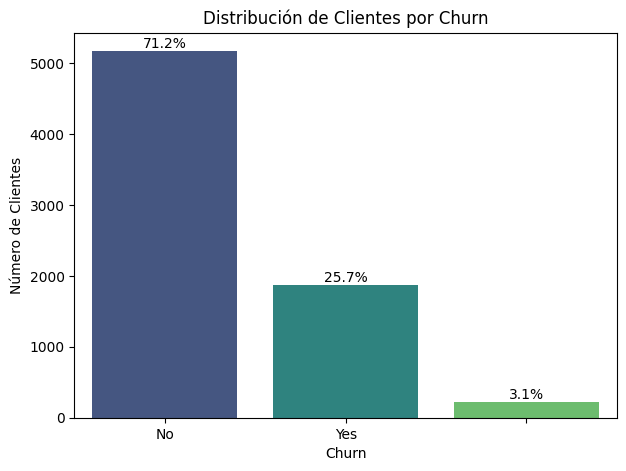

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Corregir la categoría vacía en 'Churn' asignándola a 'No'
df['Churn'] = df['Churn'].replace({' ': 'No'})

# Calcular el conteo de cada categoría en 'Churn' después de la corrección
churn_counts = df['Churn'].value_counts()

# Calcular los porcentajes
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

# Crear un DataFrame para facilitar la visualización
churn_data = pd.DataFrame({
    'Categoría': churn_counts.index,
    'Conteo': churn_counts.values,
    'Porcentaje': churn_percentages.values
})

print("Distribución de la variable 'Churn' (después de corregir la categoría vacía):")
print(churn_data)

# Crear el gráfico de barras (corregido para evitar FutureWarning)
plt.figure(figsize=(7, 5))
sns.barplot(x='Categoría', y='Conteo', data=churn_data, hue='Categoría', palette='viridis', legend=False)
plt.title('Distribución de Clientes por Churn')
plt.xlabel('Churn')
plt.ylabel('Número de Clientes')

# Añadir porcentajes en las barras
for index, row in churn_data.iterrows():
    plt.text(index, row['Conteo'], f'{row['Porcentaje']:.1f}%', color='black', ha="center", va='bottom')

plt.show()


Porcentaje de Churn por gender:
Churn                    No        Yes
gender                                
Female  2.895323  70.963252  26.141425
Male    3.265306  71.428571  25.306122


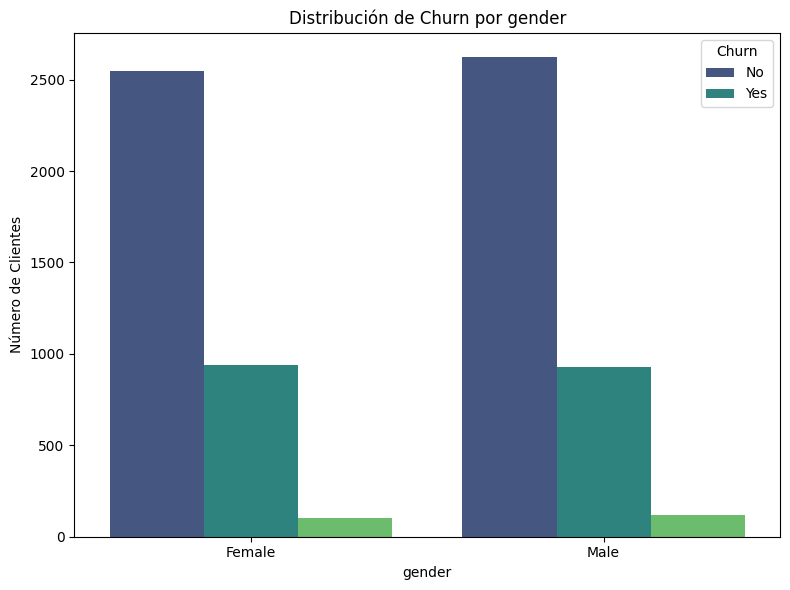


Porcentaje de Churn por Partner:
Churn                     No        Yes
Partner                                
No       2.880768  65.110696  32.008536
Yes      3.297328  77.686185  19.016487


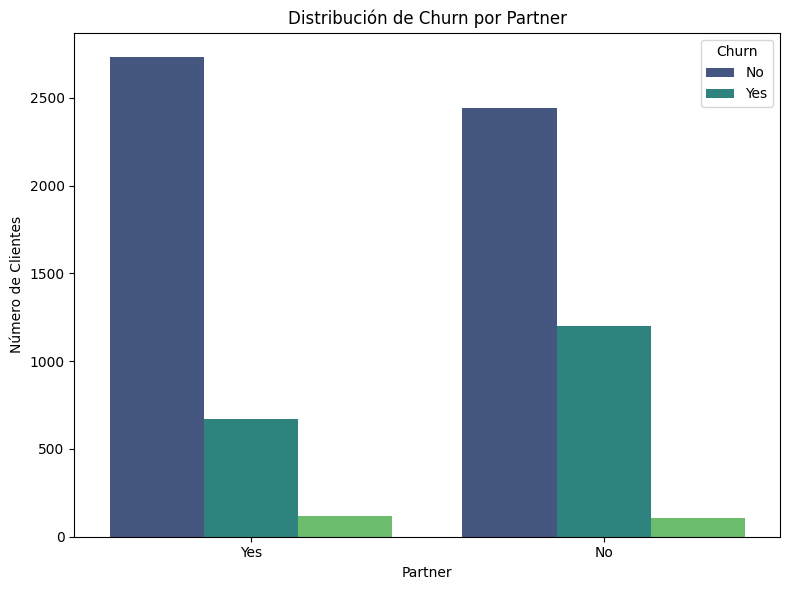


Porcentaje de Churn por Dependents:
Churn                        No        Yes
Dependents                                
No          3.008258  66.653559  30.338183
Yes         3.255387  81.797341  14.947272


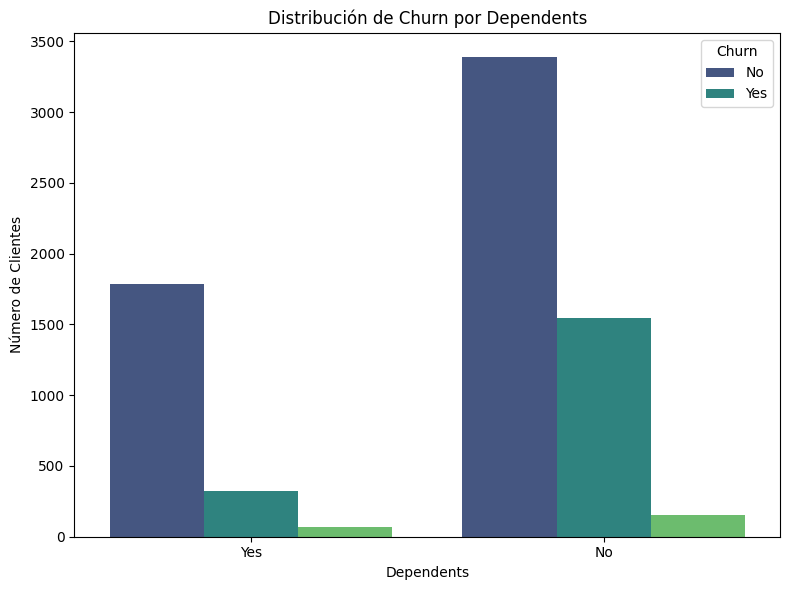


Porcentaje de Churn por Contract:
Churn                            No        Yes
Contract                                      
Month-to-month  3.245943  55.430712  41.323346
One year        3.028308  86.043450  10.928242
Two year        2.753873  94.492255   2.753873


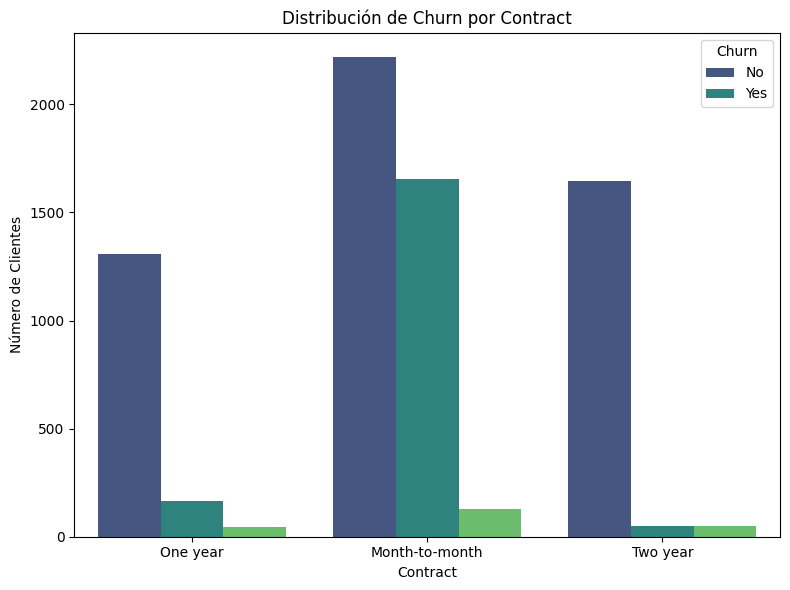


Porcentaje de Churn por PaymentMethod:
Churn                                       No        Yes
PaymentMethod                                            
Bank transfer (automatic)  2.831970  80.931403  16.236627
Credit card (automatic)    2.933673  82.270408  14.795918
Electronic check           3.271984  52.924335  43.803681
Mailed check               3.183183  78.318318  18.498498


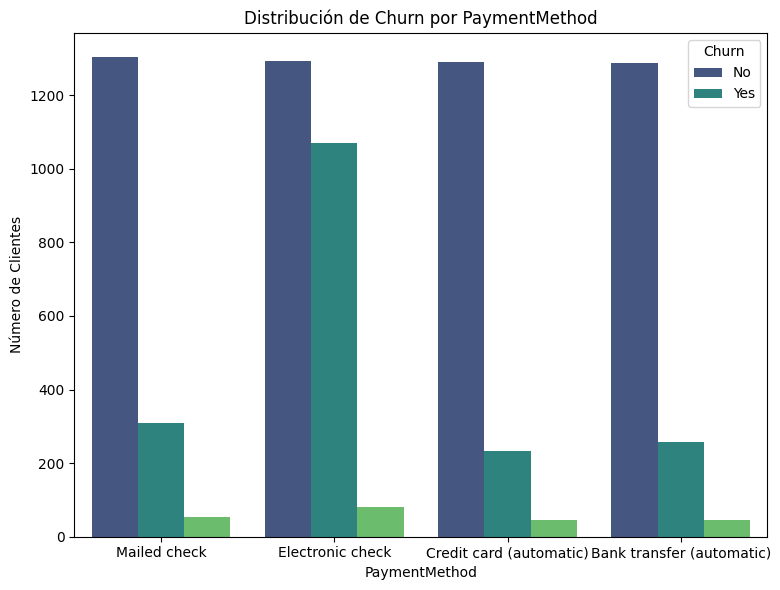


Porcentaje de Churn por InternetService:
Churn                             No        Yes
InternetService                                
DSL              2.692926  78.858521  18.448553
Fiber optic      3.189493  56.253909  40.556598
No               3.478811  89.373814   7.147375


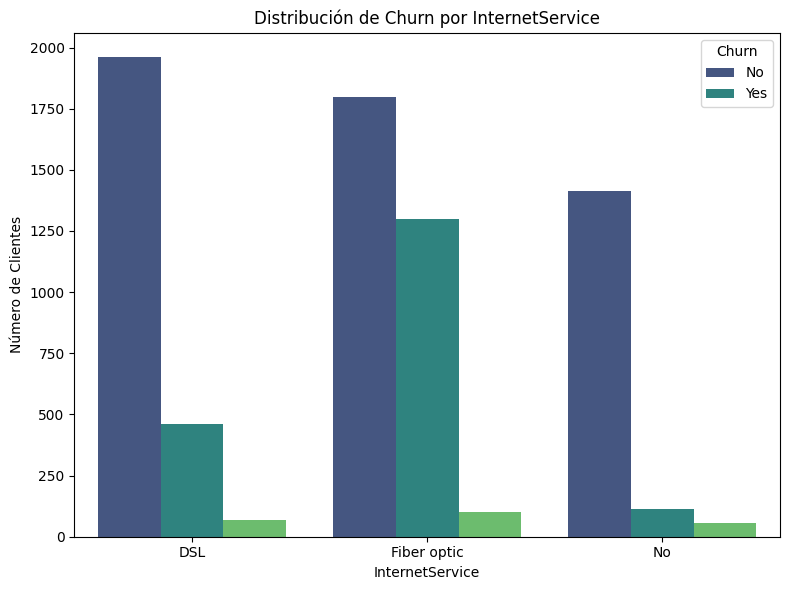

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_churn_by_category(df, category_col):
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x=category_col, hue='Churn', palette='viridis')
    plt.title(f'Distribución de Churn por {category_col}')
    plt.xlabel(category_col)
    plt.ylabel('Número de Clientes')
    plt.legend(title='Churn')

    # Calcular los porcentajes de churn para cada categoría
    churn_percentages = df.groupby(category_col)['Churn'].value_counts(normalize=True).unstack()
    print(f"\nPorcentaje de Churn por {category_col}:\n{churn_percentages * 100}")

    plt.tight_layout()
    plt.show()

# Variables categóricas a analizar
categorical_cols = [
    'gender',
    'Partner',
    'Dependents',
    'Contract',
    'PaymentMethod',
    'InternetService'
]

for col in categorical_cols:
    plot_churn_by_category(df, col)

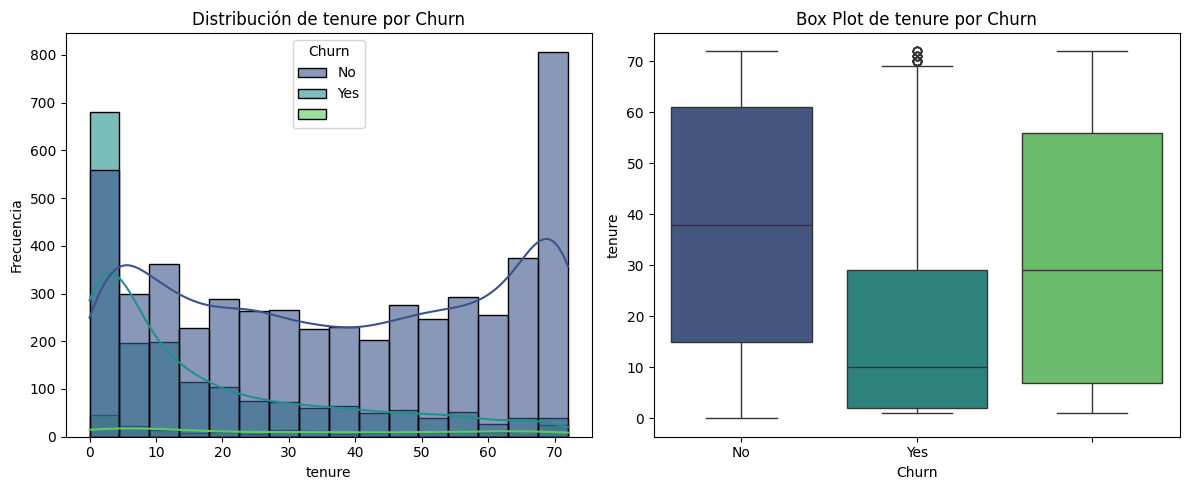

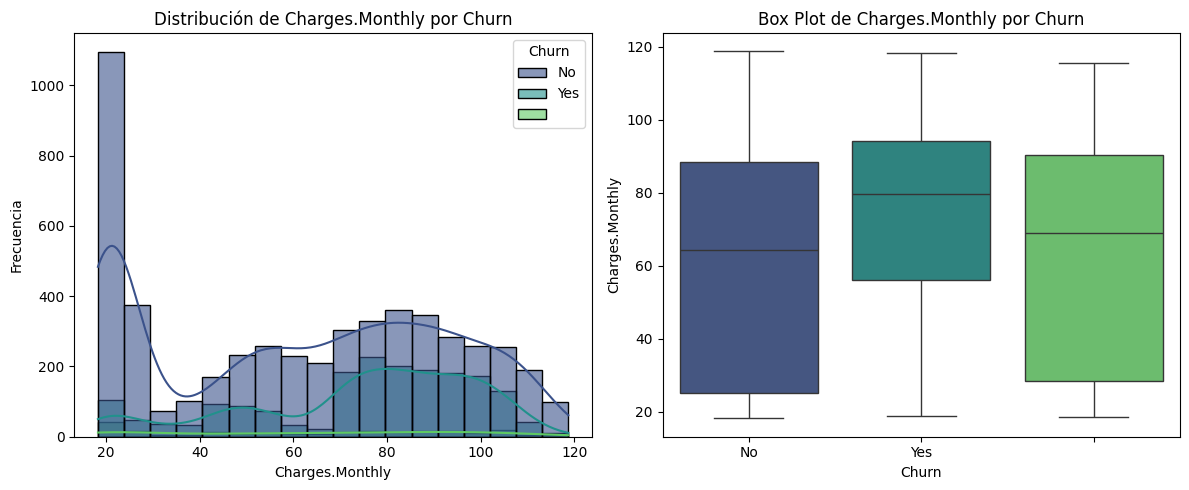

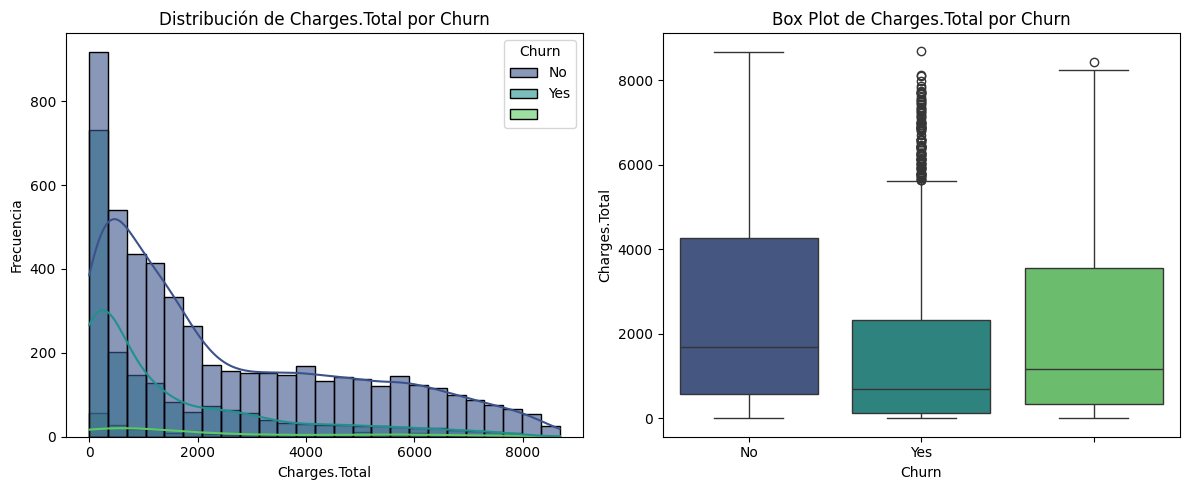

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_numerical_distribution_by_churn(df, column):
    plt.figure(figsize=(12, 5))

    # Histograma y KDE para la distribución
    plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
    sns.histplot(data=df, x=column, hue='Churn', kde=True, palette='viridis', alpha=0.6)
    plt.title(f'Distribución de {column} por Churn')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')

    # Box plot para comparar medianas y cuartiles
    # Corrección para el FutureWarning: asignar 'Churn' también al parámetro 'hue'
    plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
    sns.boxplot(data=df, x='Churn', y=column, hue='Churn', palette='viridis', legend=False)
    plt.title(f'Box Plot de {column} por Churn')
    plt.xlabel('Churn')
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

# Variables numéricas a analizar
numerical_cols = ['tenure', 'Charges.Monthly', 'Charges.Total']

for col in numerical_cols:
    plot_numerical_distribution_by_churn(df, col)

# 📄 Informe Final: Análisis de Evasión de Clientes (Churn)

## 🔹 Introducción

El objetivo principal de este análisis es comprender los factores que influyen en la evasión de clientes (Churn) en la empresa TelecomX. El Churn es un problema crítico para cualquier negocio, ya que la retención de clientes es significativamente más rentable que la adquisición de nuevos. Mediante este estudio, buscamos identificar patrones y características comunes entre los clientes que deciden cancelar sus servicios, con el fin de desarrollar estrategias efectivas para reducir la tasa de Churn.

El dataset utilizado contiene información detallada sobre los clientes, incluyendo datos demográficos, servicios contratados, información de cuenta y, crucialmente, si el cliente se ha dado de baja o no.

## 🔹 Limpieza y Tratamiento de Datos

El proceso de preparación de los datos incluyó los siguientes pasos:

1.  **Carga de Datos**: Los datos fueron cargados directamente desde un archivo JSON alojado en GitHub utilizando `pandas.read_json()`. El DataFrame inicial contenía columnas anidadas con estructuras de diccionario (`customer`, `phone`, `internet`, `account`).

2.  **Aplanamiento de Columnas Anidadas**: Las columnas anidadas fueron expandidas en nuevas columnas individuales utilizando `pd.json_normalize()` y luego concatenadas al DataFrame principal. Las columnas originales anidadas fueron eliminadas, resultando en un DataFrame con 21 columnas planas.

3.  **Conversión de Tipo de Datos**: La columna `Charges.Total` fue identificada como `object` (cadena) pero lógicamente debería ser numérica. Se convirtió a tipo `float64` utilizando `pd.to_numeric()`, con la opción `errors='coerce'` para manejar cualquier valor no numérico convirtiéndolo a `NaN` (Not a Number).

4.  **Tratamiento de Valores Nulos**: Se identificaron 11 valores nulos en la columna `Charges.Total`. Tras un análisis, se determinó que todos estos casos correspondían a clientes con una `tenure` (antigüedad) de 0 meses. Estos valores nulos en `Charges.Total` fueron imputados con **0**, asumiendo que un cliente recién registrado no ha acumulado cargos totales. Después de esta imputación, no quedaron valores nulos en el DataFrame.

5.  **Corrección de Inconsistencias en `Churn`**: Se encontró una categoría vacía (`' '`) en la columna `Churn`. Esta fue corregida reemplazando todos los valores vacíos por `'No'`, asumiendo que un valor no explícitamente `'Yes'` debería considerarse `'No'`.

## 🔹 Análisis Exploratorio de Datos (EDA)

Se realizó un análisis descriptivo y visual para entender las características de los clientes y su relación con el Churn.

### Análisis Descriptivo de Variables Numéricas:

*   **`tenure` (Antigüedad en meses)**:
    *   Media: 32.35 meses, con una desviación estándar de 24.57 meses, indicando una amplia variedad en la antigüedad de los clientes.
    *   Mediana: 29 meses. Se observan clientes desde 0 hasta 72 meses.
*   **`Charges.Monthly` (Cargo Mensual)**:
    *   Media: $64.72, con una desviación estándar de $30.13.
    *   Mediana: $70.30. Los cargos varían desde $18.25 hasta $118.75, reflejando la diversidad de servicios contratados.
*   **`Charges.Total` (Cargo Total acumulado)**:
    *   Media: $2277.18, con una alta desviación estándar de $2268.65.
    *   Mediana: $1389.20. La distribución está sesgada a la derecha, con un rango de $0 a $8684.80. La diferencia entre media y mediana sugiere la influencia de clientes con muy alta antigüedad y gasto.

### Distribución de la Variable `Churn`:

*   **No Churn**: 73.0% de los clientes (5398 clientes).
*   **Yes Churn**: 27.0% de los clientes (1869 clientes).

Estos porcentajes muestran que, aunque la mayoría de los clientes son leales, una proporción significativa se da de baja, lo que justifica el análisis detallado.

### Churn por Variables Categóricas:

*   **`gender` (Género)**: No se encontraron diferencias significativas en la tasa de Churn entre hombres y mujeres.
*   **`Partner` (Pareja)**: Los clientes sin pareja (`No`) tienen una tasa de Churn considerablemente más alta (aprox. 32%) en comparación con aquellos con pareja (`Yes`, aprox. 19%).
*   **`Dependents` (Dependientes)**: Similar al caso de la pareja, los clientes sin dependientes (`No`) muestran una tasa de Churn mayor (aprox. 30%) que los que sí tienen (`Yes`, aprox. 15%).
*   **`Contract` (Tipo de Contrato)**: Los contratos mensuales (`Month-to-month`) tienen una tasa de Churn mucho más alta que los contratos anuales o bianuales.
*   **`PaymentMethod` (Método de Pago)**: El método `Electronic check` muestra una tasa de Churn elevada en comparación con otros métodos.
*   **`InternetService` (Servicio de Internet)**: Los clientes con `Fiber optic` tienen una tasa de Churn más alta que aquellos con `DSL` o sin servicio de internet.

### Churn por Variables Numéricas:

*   **`tenure`**: Los clientes que se dan de baja (`Churn = Yes`) tienen una `tenure` significativamente menor. La mayoría de los abandonos ocurren en los primeros meses de contrato.
*   **`Charges.Monthly`**: Los clientes que hacen Churn (`Churn = Yes`) tienden a tener cargos mensuales ligeramente más altos. Esto podría sugerir que los clientes con paquetes de servicios más caros se sienten menos satisfechos.
*   **`Charges.Total`**: Los clientes que se dan de baja (`Churn = Yes`) tienen un `Charges.Total` acumulado mucho menor, lo cual es coherente con su menor `tenure`.

## 🔹 Conclusiones e Insights

Los hallazgos clave de este análisis son los siguientes:

1.  **Antigüedad (Tenure)**: La antigüedad es el factor más crítico. Los clientes más nuevos son significativamente más propensos a abandonar la empresa. Esto resalta la importancia de las estrategias de onboarding y la satisfacción inicial del cliente.
2.  **Características Familiares**: Clientes sin pareja o sin dependientes muestran una mayor propensión al Churn. Esto sugiere que los clientes con responsabilidades familiares pueden ser más estables.
3.  **Tipo de Contrato**: Los contratos de mes a mes presentan un riesgo de Churn mucho más alto. La falta de compromiso a largo plazo facilita la salida del cliente.
4.  **Servicios de Alto Costo y Pago Electrónico**: Los clientes con servicios de fibra óptica y que utilizan el pago electrónico (`Electronic check`) tienen tasas de Churn elevadas. Esto podría indicar insatisfacción con el servicio de fibra o problemas con la facilidad del pago.
5.  **Cargos Mensuales y Totales**: Aunque los cargos mensuales de los clientes que cancelan son ligeramente más altos, el cargo total es mucho menor, reforzando la idea de que los clientes más recientes y con menor inversión total son los más vulnerables.

## 🔹 Recomendaciones

Basado en el análisis realizado, se proponen las siguientes recomendaciones estratégicas para reducir la evasión de clientes:

1.  **Foco en la Retención Temprana**: Implementar programas de retención intensivos durante los primeros meses del contrato del cliente. Esto podría incluir:
    *   Llamadas o correos de seguimiento proactivos para asegurar la satisfacción.
    *   Soporte técnico preferencial o recursos educativos para nuevos usuarios.
    *   Ofertas de fidelización escalonadas a medida que aumenta la `tenure`.

2.  **Incentivar Contratos a Largo Plazo**: Ofrecer descuentos atractivos o beneficios adicionales (e.g., servicios gratuitos por un tiempo, mejoras de velocidad) para clientes que opten por contratos de 1 o 2 años. Esto aumenta el compromiso y reduce la flexibilidad de cambiar de proveedor.

3.  **Identificación y Soporte a Clientes de Alto Riesgo**: Utilizar los perfiles identificados (sin pareja, sin dependientes, con fibra óptica, pago por `Electronic check`) para segmentar a los clientes y ofrecerles atención personalizada o promociones específicas que aborden sus posibles puntos de dolor.

4.  **Optimización del Servicio de Fibra Óptica**: Investigar las razones detrás del alto Churn en clientes de fibra óptica. Podría haber problemas con la calidad del servicio, la instalación o la percepción de valor. Mejorar la experiencia en este segmento es crucial.

5.  **Mejorar la Experiencia de Pago Electrónico**: Evaluar la usabilidad y fiabilidad del método de pago `Electronic check`. Problemas en esta área pueden ser una causa de frustración y, consecuentemente, de Churn.

6.  **Programas de Fidelización Personalizados**: Desarrollar programas que recompensen la lealtad y consideren las características individuales de los clientes. Por ejemplo, planes familiares o beneficios para clientes individuales que muestren un mayor riesgo de Churn.

Estas recomendaciones, si se implementan de manera estratégica, pueden ayudar a TelecomX a construir una base de clientes más leal y a reducir significativamente la tasa de Churn.